# Quantum Noise Channels and Bloch Sphere Trajectories

This notebook explores standard open quantum system noise models (**amplitude damping**, **pure dephasing**, and **thermal relaxation**) and visualizes the resulting decoherence trajectories on the **Bloch Sphere**.

## 1. Noise Channels Theory

In open quantum systems, interaction with the environment induces noise. We model these using specific jump (collapse) operators $L_k$ in the Lindblad equation:

### 1.1 Amplitude Damping ($T_1$)
Models energy relaxation, where the qubit decays from the excited state $|1\rangle$ to the ground state $|0\rangle$ with rate $\gamma = 1/T_1$.
- Collapse operator: $L_1 = \sigma_- = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}$.
- Expected decay of population: $P_1(t) = P_1(0) e^{-t/T_1}$, and the Bloch component $Z$ decays as $z(t) = 1 - (1 - z(0))e^{-t/T_1}$.

### 1.2 Pure Dephasing ($T_2$)
Models phase randomization without changing state populations. It destroys coherence (off-diagonal terms) with rate $\gamma = 1/(2T_2)$.
- Collapse operator: $L_1 = \sigma_z = \begin{pmatrix} 1 & 0 \\ 0 & -1 \end{pmatrix}$.
- Expected decay of coherences: $\rho_{01}(t) = \rho_{01}(0) e^{-t/T_2}$.

### 1.3 Thermal Relaxation
Models coupling to a thermal bath with temperature $T$. The environmental thermal occupancy $n_{th}$ modifies the excitation and relaxation rates:
- Up-transition rate: $\gamma_{\text{up}} = \frac{n_{th}}{T_1}$ with collapse operator $L_1 = \sigma_+$.
- Down-transition rate: $\gamma_{\text{down}} = \frac{n_{th} + 1}{T_1}$ with collapse operator $L_2 = \sigma_-$.
- Dephasing rate: $\gamma_{d} = \frac{1}{2} \left( \frac{1}{T_2} - \frac{1}{2T_1} \right)$ with collapse operator $L_3 = \sigma_z$.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

# Re-import/define core functions to keep this notebook self-contained
def pauli_matrices():
    return (
        np.array([[0, 1], [1, 0]], dtype=complex),
        np.array([[0, -1j], [1j, 0]], dtype=complex),
        np.array([[1, 0], [0, -1]], dtype=complex)
    )

def spin_operators():
    return (
        np.array([[0, 1], [0, 0]], dtype=complex), # sm = |g><e|
        np.array([[0, 0], [1, 0]], dtype=complex)  # sp = |e><g|
    )

def bloch_vector(rho):
    sx, sy, sz = pauli_matrices()
    return np.array([
        np.trace(rho @ sx).real,
        np.trace(rho @ sy).real,
        np.trace(rho @ sz).real
    ])

def lindblad_superoperator(H, L_list, gamma_list):
    n = H.shape[0]
    I = np.eye(n)
    L = -1j * (np.kron(I, H) - np.kron(H.T, I))
    for Lk, gk in zip(L_list, gamma_list):
        term1 = np.kron(Lk.conj(), Lk)
        Lk_dag_Lk = Lk.conj().T @ Lk
        term2 = -0.5 * np.kron(I, Lk_dag_Lk)
        term3 = -0.5 * np.kron(Lk_dag_Lk.T, I)
        L += gk * (term1 + term2 + term3)
    return L

def lindblad_solve(H, rho0, tlist, L_list, gamma_list):
    n = H.shape[0]
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    rho0_vec = rho0.reshape(-1, order='F')
    rhos = []
    for t in tlist:
        rho_t_vec = expm(L_op * t) @ rho0_vec
        rhos.append(rho_t_vec.reshape(n, n, order='F'))
    return np.array(rhos)

## 2. Solver Functions for Specific Noise Channels

In [ ]:
def amplitude_damping(rho0, tlist, T1):
    H = np.zeros((2, 2), dtype=complex)
    sm, _ = spin_operators()
    return lindblad_solve(H, rho0, tlist, [sm], [1.0 / T1])

def dephasing(rho0, tlist, T2):
    H = np.zeros((2, 2), dtype=complex)
    _, _, sz = pauli_matrices()
    return lindblad_solve(H, rho0, tlist, [sz], [1.0 / (2 * T2)])

def amplitude_damping_dephasing(rho0, tlist, T1, T2):
    gamma_d = 1.0 / T2 - 1.0 / (2 * T1)
    if gamma_d < 0:
        raise ValueError(f"T2={T2} cannot be less than 2*T1={2*T1}")
    H = np.zeros((2, 2), dtype=complex)
    sm, _ = spin_operators()
    _, _, sz = pauli_matrices()
    return lindblad_solve(H, rho0, tlist, [sm, sz], [1.0 / T1, gamma_d / 2])

## 3. Custom 3D Bloch Sphere Visualization

We build a custom 3D Bloch sphere visualizer using matplotlib's 3D toolkit.

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def plot_bloch_sphere(ax=None):
    if ax is None:
        fig = plt.figure(figsize=(6, 6))
        ax = fig.add_subplot(111, projection='3d')
        
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_zlim(-1.3, 1.3)
    
    # Draw wireframe sphere
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x, y, z, color='gray', alpha=0.1, rstride=2, cstride=2)

    # Draw axes
    for axis, color in [(np.array([1, 0, 0]), 'r'), (np.array([0, 1, 0]), 'g'), (np.array([0, 0, 1]), 'b')]:
        ax.plot([-axis[0], axis[0]], [-axis[1], axis[1]], [-axis[2], axis[2]], color=color, alpha=0.4, lw=1)

    # Add labels
    ax.text(1.2, 0, 0, '|+⟩', color='r')
    ax.text(-1.3, 0, 0, '|−⟩', color='r')
    ax.text(0, 1.2, 0, '|+i⟩', color='g')
    ax.text(0, -1.4, 0, '|−i⟩', color='g')
    ax.text(0, 0, 1.2, '|0⟩', color='b')
    ax.text(0, 0, -1.3, '|1⟩', color='b')
    
    ax.set_axis_off()
    return ax

def plot_trajectory(bloch_vectors, ax, color, label):
    bv = np.array(bloch_vectors)
    ax.plot(bv[:, 0], bv[:, 1], bv[:, 2], color=color, lw=2, label=label)
    # Initial state
    ax.scatter([bv[0, 0]], [bv[0, 1]], [bv[0, 2]], color=color, s=50, marker='o')
    # Final state
    ax.scatter([bv[-1, 0]], [bv[-1, 1]], [bv[-1, 2]], color=color, s=100, marker='*')

## 4. Simulation and Visualization of Noise Channels

We simulate the T1 decay of a state initially prepared in the excited state $|1\rangle$ and dephasing of a superposition state $|+\rangle = (|0\rangle + |1\rangle)/\sqrt{2}$.

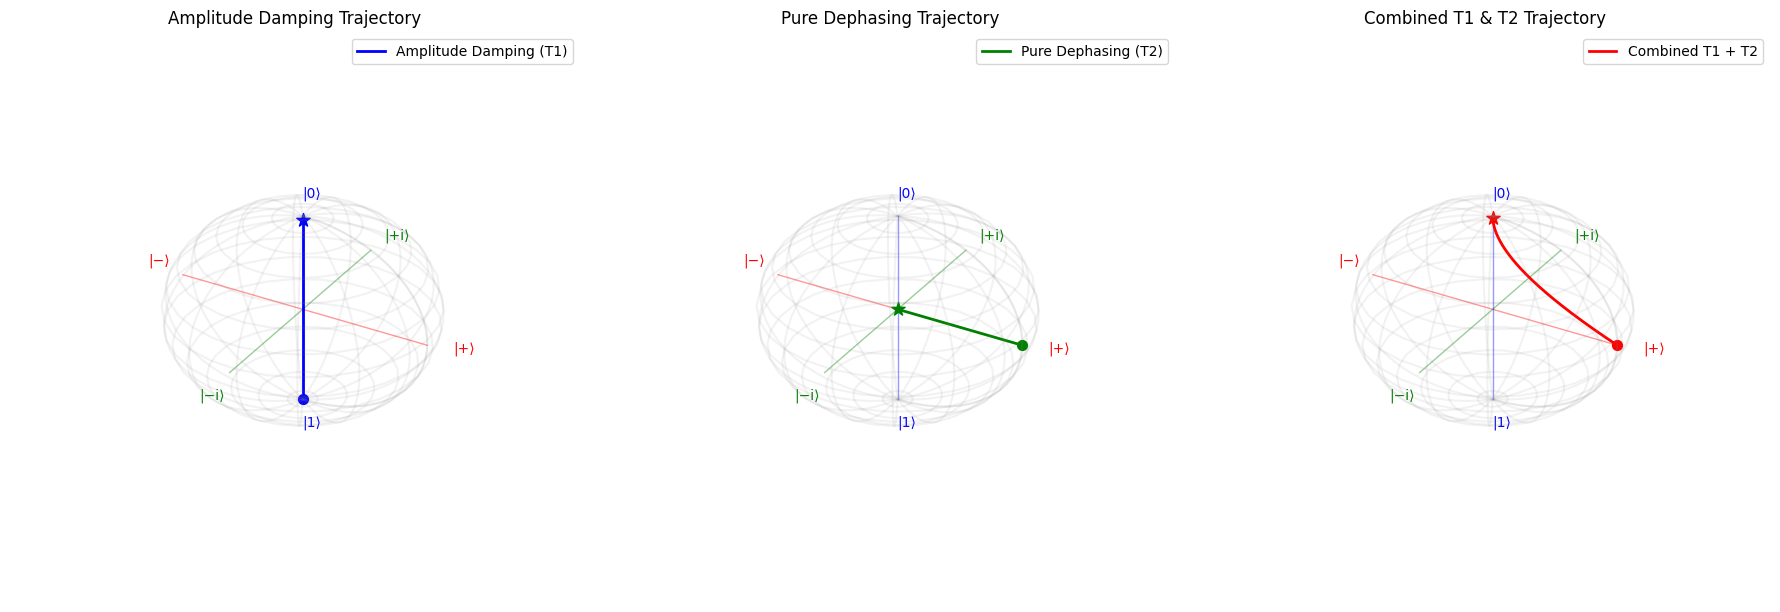

In [ ]:
T1 = 10.0
T2 = 5.0
tlist = np.linspace(0, 40, 300)

# Prepare states
rho_excited = np.array([[0, 0], [0, 1]], dtype=complex) # |1><1|
rho_superpos = np.array([[0.5, 0.5], [0.5, 0.5]], dtype=complex) # |+><+|

# Runs
rhos_ad = amplitude_damping(rho_excited, tlist, T1)
rhos_dp = dephasing(rho_superpos, tlist, T2)
rhos_both = amplitude_damping_dephasing(rho_superpos, tlist, T1, T2)

# Compute Bloch vectors
bvs_ad = [bloch_vector(r) for r in rhos_ad]
bvs_dp = [bloch_vector(r) for r in rhos_dp]
bvs_both = [bloch_vector(r) for r in rhos_both]

# Plot
fig = plt.figure(figsize=(18, 6))

ax1 = fig.add_subplot(131, projection='3d')
plot_bloch_sphere(ax1)
plot_trajectory(bvs_ad, ax1, 'blue', 'Amplitude Damping (T1)')
ax1.set_title('Amplitude Damping Trajectory')
ax1.legend()

ax2 = fig.add_subplot(132, projection='3d')
plot_bloch_sphere(ax2)
plot_trajectory(bvs_dp, ax2, 'green', 'Pure Dephasing (T2)')
ax2.set_title('Pure Dephasing Trajectory')
ax2.legend()

ax3 = fig.add_subplot(133, projection='3d')
plot_bloch_sphere(ax3)
plot_trajectory(bvs_both, ax3, 'red', 'Combined T1 + T2')
ax3.set_title('Combined T1 & T2 Trajectory')
ax3.legend()

plt.tight_layout()
plt.show()

### Decay Envelopes vs Analytical Predictions
Let's check the analytical accuracy of our custom solver by plotting the calculated decay envelopes alongside the exact analytical solutions.

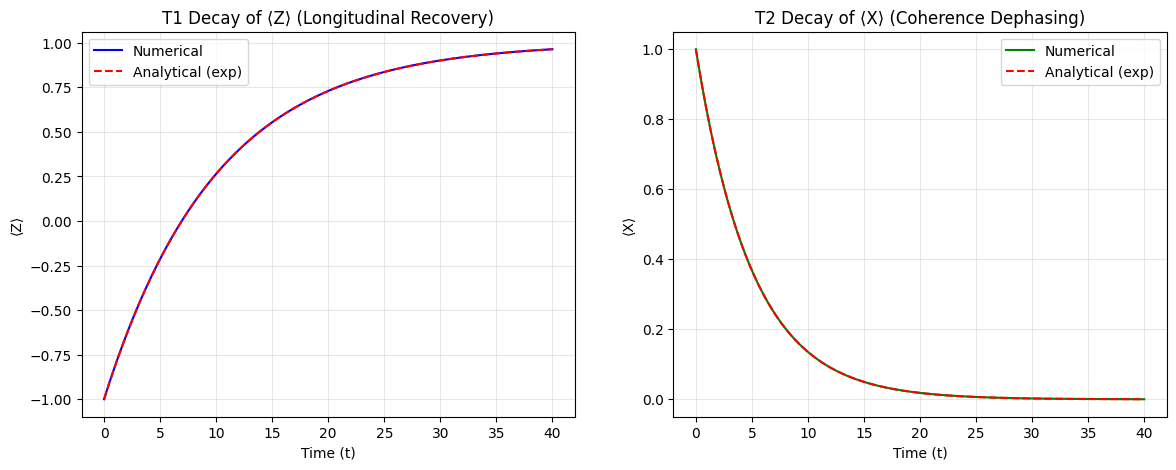

In [ ]:
# Z component decay for T1
z_num = [bv[2] for bv in bvs_ad]
z_ana = 1.0 - 2.0 * np.exp(-tlist / T1) # starts at -1 (|1>), relaxes to 1 (|0>)

# X component decay for T2
x_num = [bv[0] for bv in bvs_dp]
x_ana = np.exp(-tlist / T2) # starts at 1 (|+>), decays to 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(tlist, z_num, 'b-', label='Numerical')
ax1.plot(tlist, z_ana, 'r--', label='Analytical (exp)')
ax1.set_xlabel('Time (t)')
ax1.set_ylabel('⟨Z⟩')
ax1.set_title('T1 Decay of ⟨Z⟩ (Longitudinal Recovery)')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(tlist, x_num, 'g-', label='Numerical')
ax2.plot(tlist, x_ana, 'r--', label='Analytical (exp)')
ax2.set_xlabel('Time (t)')
ax2.set_ylabel('⟨X⟩')
ax2.set_title('T2 Decay of ⟨X⟩ (Coherence Dephasing)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.show()